## Trees, Trees, more Trees, oh my!!

In this notebook, we demonstrate how one might use some of the learning algorithms implemented in geomstats to apply to a non-Euclidean geodesic metric space.

We choose BHV space, which is the space of unrooted phylogenetic trees without pendant edges.

We will then demonstrate geodesic, computation of the Fréchet mean using Sturm's algorithm, and then k-means clustering.

We first will use a simulated dataset for convenience and prettiness.

In a separate notebook will use a subset of a phylogenetic tree dataset to demonstrate application to real-world data.


## 1. Imports and helper functions

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

import geomstats.backend as gs
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.learning.knn import KNearestNeighborsClassifier
from geomstats.metric_geometry.bhv_space import (
    Tree,
    TreeSpace,
)
from geomstats.metric_geometry.trees import Split

gs.random.seed(2026)

In [116]:
def _draw_quadrant_plot(ax, max_xy=5):
    ax.axhline(0, color="#e08020", lw=2.0, zorder=2)  # orange horizontal
    ax.axvline(0, color="#3aaa6a", lw=2.0, zorder=2)  # green vertical

    # Light blue background for all quadrants
    ax.set_facecolor("#dde5f5")

    # Gray top-left quadrant
    ax.fill_betweenx([0, max_xy], -max_xy, 0, color="#d0d0d0", alpha=0.85, zorder=0)

    # Quadrant labels
    font_kw = dict(fontsize=11, fontweight="bold", color="#222")
    ax.text(0.05, max_xy - 0.15, "34|012", va="top", ha="left", **font_kw)
    ax.text(-max_xy + 0.05, -0.05, "04|123", va="top", ha="left", **font_kw)
    ax.text(max_xy - 0.05, -0.05, "01|234", va="top", ha="right", **font_kw)
    ax.text(0.05, -max_xy + 0.15, "23|014", va="bottom", ha="left", **font_kw)

    ax.set_xlim(-max_xy, max_xy)
    ax.set_ylim(-max_xy, max_xy)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=9)
    ax.grid(False)
    ax.set_title("One Quadrant in BHV(5)")


def _draw_tree_on_quadrant(ax, tree, marker="o", label="", c="r", alpha=1.0, ms=10):
    # calculate where to go on plot
    x, y = 0, 0
    for split, length in zip(tree.topology.splits, tree.lengths):
        small_split = split.part1 if len(split.part1) == 2 else split.part2
        if small_split == {0, 1}:
            # positive x-axis
            x = length
        elif small_split == {0, 4}:
            x = -length
        elif small_split == {3, 4}:
            y = length
        elif small_split == {2, 3}:
            y = -length
        else:
            print("Oops, this shouldn't happen")

    ax.plot(x, y, marker, ms=ms, color=c, zorder=5, alpha=alpha)
    ax.text(x, y + 0.35, label, fontsize=8, color=c, zorder=6)

## 2. Construct and visualise simulated dataset

We will be working in BHV(5), which is the space of unrooted, labeled trees with five labels. This is the simplest of the spaces, which still maintains some of the interesting (ie, non-Eucliean) properties of the space, such as sticky mean (more on that later).

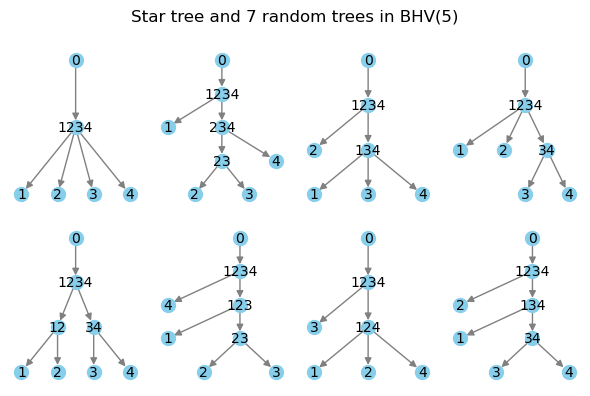

In [68]:
# BHV space only defined with N >= 4
bhv5 = TreeSpace(n_labels=5)

# This is the star tree, with no interior splits
star_tree = Tree((), [], n_labels=5)

# Let's make 7 more random trees
N_RANDOM_TREES = 7
random_trees = bhv5.random_point(N_RANDOM_TREES)

trees = [star_tree] + random_trees

fig, axes = plt.subplots(2, N_RANDOM_TREES // 2 + 1, figsize=(6, 4))
axes = axes.flatten()
for i, tree in enumerate(trees):
    # root_id is just for visualisation, so we know how to hang the tree
    tree.plot(root_id=0, ax=axes[i])
plt.suptitle(f"Star tree and {N_RANDOM_TREES} random trees in BHV(5)")
plt.tight_layout()
plt.show()

## 3. Geodesic

Here is a nice website to visualise how three orthants are related https://plewis.github.io/applets/bhvspace/ and how points in those orthants are connected by geodesics (distance-minimising paths). The star tree is located at the origin.

In BHV(5) there are four different types of geodesics:
- inner-orthant, meaning just interior split lengths change, but no splits are created and none are destroyed. This is the same as a straight line in Euclidean space
- edge-ending, meaning the geodesic ends on a lower-dimensional stratum, here a line or point. This means a split was destroyed (mutatis mutandum edge-starting geodesics start on a lower-dimensional stratum and enter a higher-dimensional one, creating a split)
- "straight" intra-orthant, in here a split is destroyed and another is created, and the geodesic traverses from a higher-dimensional plane, through the lower-dimensional stratum, and to another higher-dimensional stratum, but the line is straight (in BHV(5): 2d->1d->2d)
- "bent" intra-orthant, in this one, the shortest path one passes through the origin (star tree)! and looks like a bent line. Here all interior splits dissapear and then new ones are created (in BHV(5): 2d->0d->2d)


### Inner-orthant geodesic

In [69]:
top_quadrant_topology = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))

top_tree = Tree(top_quadrant_topology, [3, 1])
top_tree_shifted = Tree(top_quadrant_topology, [1, 4])

top_trees = [top_tree, top_tree_shifted]

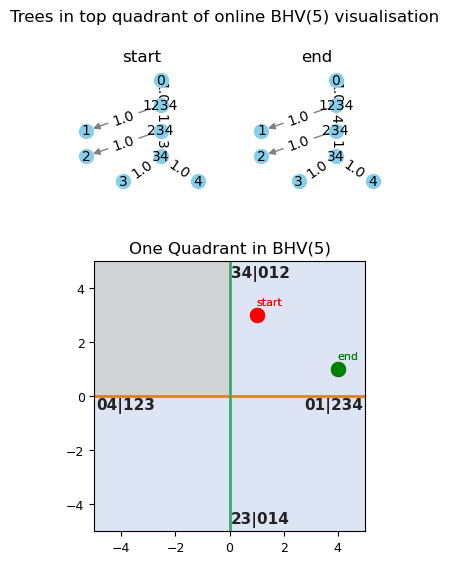

In [70]:
fig = plt.figure(figsize=(4, 6), facecolor="white")
grid = GridSpec(
    2, max(2, 1), figure=fig, height_ratios=[1, 2.2], hspace=0.35, wspace=0.3
)

top_trees = [top_tree, top_tree_shifted]
labels = ["start", "end"]
for i, tree in enumerate(top_trees):
    ax = fig.add_subplot(grid[0, i])
    tree.plot(root_id=0, show_edge_weights=True, ax=ax)
    ax.set_title(labels[i])

ax_quad = fig.add_subplot(grid[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
colors = ["red", "green"]
for i, tree in enumerate(top_trees):
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])

plt.suptitle("Trees in top quadrant of online BHV(5) visualisation")
plt.show()

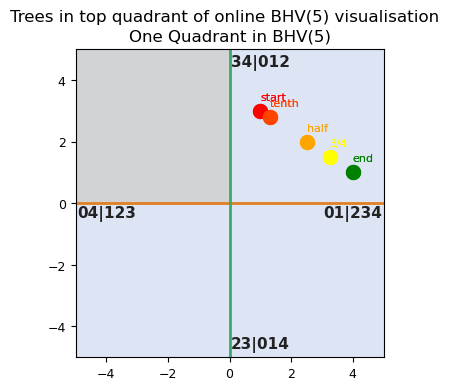

In [71]:
## Geodesic same quadrant
geodesic = bhv5.metric.geodesic(top_trees[0], top_trees[-1])
beginning = geodesic(0)[0]
tenth = geodesic(0.1)[0]
halfway = geodesic(0.5)[0]
three_quarters = geodesic(0.75)[0]
end = geodesic(1)[0]

geodesic_trees = [beginning, tenth, halfway, three_quarters, end]
labels = ["start", "tenth", "half", "3/4", "end"]
colors = ["red", "orangered", "orange", "yellow", "green"]

# Let's draw the geodesic!!
fig, ax = plt.subplots(1, 1, figsize=(4, 4), facecolor="white")
_draw_quadrant_plot(ax, max_xy=5)
for i, tree in enumerate(geodesic_trees):
    _draw_tree_on_quadrant(ax, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax, tree, c=colors[i], label=labels[i])

plt.suptitle("Trees in top quadrant of online BHV(5) visualisation")
plt.show()

### Intra-orthant "straight" geodesic

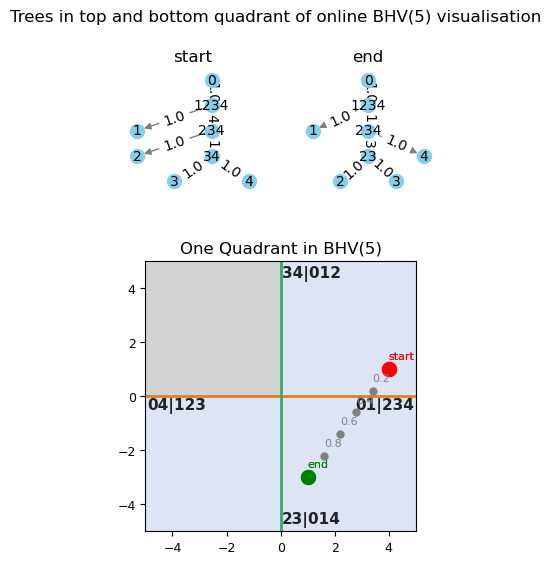

In [72]:
bottom_right_quadrant_topology = (Split({2, 3}, {0, 1, 4}), Split({0, 1}, {2, 3, 4}))

top_tree = Tree(top_quadrant_topology, [1, 4])
bottom_tree = Tree(bottom_right_quadrant_topology, [3, 1])

trees = [top_tree, bottom_tree]

fig = plt.figure(figsize=(4, 6), facecolor="white")
grid = GridSpec(
    2, max(2, 1), figure=fig, height_ratios=[1, 2.2], hspace=0.35, wspace=0.3
)

labels = ["start", "end"]
for i, tree in enumerate(trees):
    ax = fig.add_subplot(grid[0, i])
    tree.plot(root_id=0, show_edge_weights=True, ax=ax)
    ax.set_title(labels[i])

ax_quad = fig.add_subplot(grid[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
colors = ["red", "green"]
for i, tree in enumerate(trees):
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])

### ADD GEODESIC TREES
geodesic = bhv5.metric.geodesic(top_tree, bottom_tree)
for i in range(1, 5):
    tree = geodesic(i / 5)[0]
    _draw_tree_on_quadrant(ax_quad, tree, ms=5, c="grey", label=str(i / 5))

plt.suptitle("Trees in top and bottom quadrant of online BHV(5) visualisation")
plt.show()

### Intra-orthant "bent" geodesic

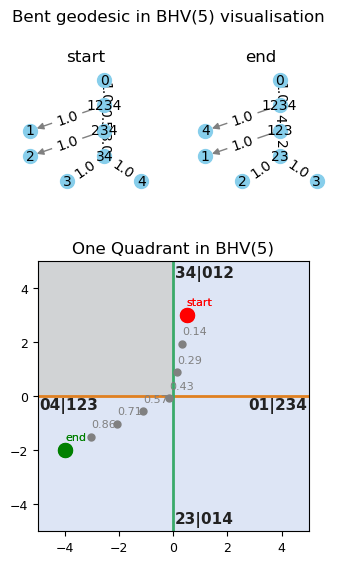

In [73]:
bottom_left_quadrant_topology = (Split({2, 3}, {0, 1, 4}), Split({0, 4}, {1, 2, 3}))

top_tree = Tree(top_quadrant_topology, [3, 0.5])
bottom_tree = Tree(bottom_left_quadrant_topology, [2, 4])

trees = [top_tree, bottom_tree]

fig = plt.figure(figsize=(4, 6), facecolor="white")
grid = GridSpec(
    2, max(2, 1), figure=fig, height_ratios=[1, 2.2], hspace=0.35, wspace=0.3
)

labels = ["start", "end"]
for i, tree in enumerate(trees):
    ax = fig.add_subplot(grid[0, i])
    tree.plot(root_id=0, show_edge_weights=True, ax=ax)
    ax.set_title(labels[i])

ax_quad = fig.add_subplot(grid[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
colors = ["red", "green"]
for i, tree in enumerate(trees):
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[i], label=labels[i])

### ADD GEODESIC TREES
geodesic = bhv5.metric.geodesic(top_tree, bottom_tree)
n_examples = 7
for i in range(1, n_examples):
    tree = geodesic(i / n_examples)[0]
    _draw_tree_on_quadrant(
        ax_quad, tree, ms=5, c="grey", label=f"{(i / n_examples):.2f}"
    )

plt.suptitle("Bent geodesic in BHV(5) visualisation")
plt.show()

## 3. Mean

Fréchet mean is computed in geodesic metric spaces (like BHV) via Sturm's algorithm. Since we do not have an `exp` in this space (undefined at origin), we can not use the typical gradient-descent approach. Instead, we use an iterative approach, which samples a point, computes the geodesic between that and the current mean estimate, walks a decreasing amount down that geodesic, rinses, and repeats. Since BHV is a CAT(0) (non-positively-curved) space, there are nice convergence guarantees.

Let's sample some random trees until we find ten in our three quadrants that we have decided to visualize!

### Mean of two random samples
Should be the same as 0.5 geodesic

In [74]:
random_trees = bhv5.random_point(2)
geodesic = bhv5.metric.geodesic(random_trees[0], random_trees[-1])
half_geodesic_tree = geodesic(0.5)[0]
print("Half geodesic tree:\t", half_geodesic_tree)

## Compute the mean!!
# Will be Sturm's algorithm by default for bhv space
mean_estimator = FrechetMean(bhv5, sample_method="cyclic", max_iter=10000, epsilon=1e-3)
mean_estimator = mean_estimator.fit(random_trees)
mean_tree = mean_estimator.estimate_
print("Frechet mean tree:\t", mean_tree)

print("Distance between:", bhv5.metric.dist(half_geodesic_tree, mean_tree))

Half geodesic tree:	 (({0, 1, 3}|{2, 4}, {0, 2, 4}|{1, 3});[0.56284043 1.03646338])
Frechet mean tree:	 (({0, 1, 3}|{2, 4}, {0, 2, 4}|{1, 3});[0.56330792 1.03732425])
Distance between: 0.00097961509188717


### Mean with 10 random samples

In [87]:
valid_trees = []
while len(valid_trees) < 10:
    random_tree = bhv5.random_point()
    tree_good = True
    for split in random_tree.topology.splits:
        small_split = split.part1 if len(split.part1) == 2 else split.part2
        if small_split not in ({0, 1}, {0, 4}, {3, 4}, {2, 3}):
            tree_good = False

    if tree_good:
        random_tree.lengths = 3 * random_tree.lengths
        valid_trees.append(random_tree)

In [ ]:
mean_estimator = FrechetMean(bhv5, sample_method="cyclic", max_iter=10000, epsilon=1e-3)
mean_estimator = mean_estimator.fit(valid_trees)
mean = mean_estimator.estimate_
print(mean)

(({0, 1, 4}|{2, 3}, {0, 1}|{2, 3, 4});[0.69169689 0.43033933])


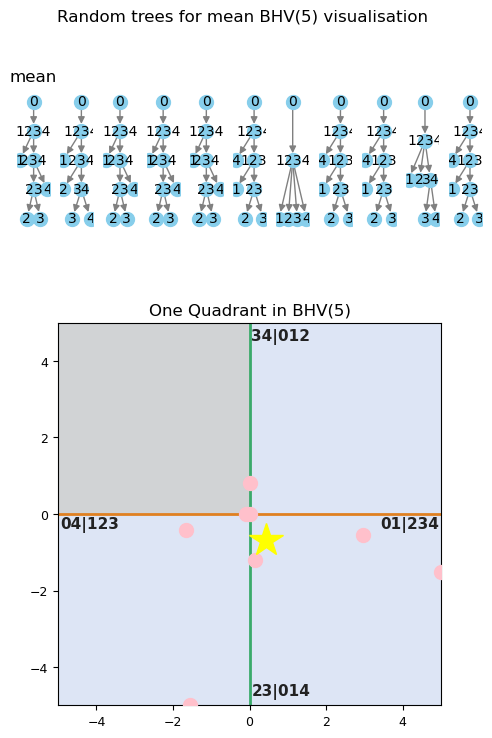

In [89]:
# Visualise with the mean as a gold star lol
fig = plt.figure(figsize=(6, 8), facecolor="white")
grid = GridSpec(
    2, len(valid_trees) + 1, figure=fig, height_ratios=[1, 2.7], hspace=0.35, wspace=0.3
)

ax = fig.add_subplot(grid[0, 0])
mean.plot(root_id=0, ax=ax)
ax.set_title("mean")

for i, tree in enumerate(valid_trees):
    ax = fig.add_subplot(grid[0, i + 1])
    tree.plot(root_id=0, show_edge_weights=False, ax=ax)

ax_quad = fig.add_subplot(grid[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
for i, tree in enumerate(valid_trees):
    _draw_tree_on_quadrant(ax_quad, tree, c="pink")

_draw_tree_on_quadrant(ax_quad, mean, marker="*", ms=25, c="yellow")

plt.suptitle("Random trees for mean BHV(5) visualisation")
plt.show()

### Sticky mean

(();[])
(();[])
(();[])
(();[])
(();[])
(();[])
(();[])


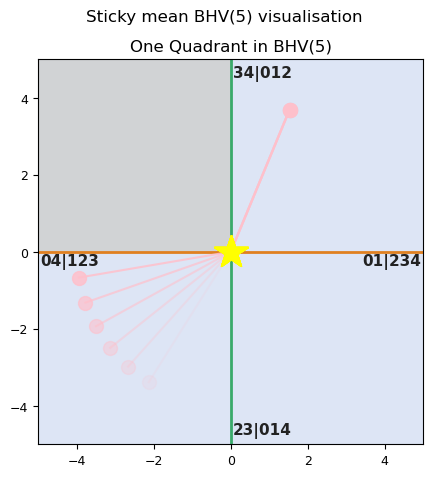

In [ ]:
top_right_quadrant_topology = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))
bottom_left_quadrant_topology = (Split({0, 4}, {1, 2, 3}), Split({2, 3}, {0, 1, 4}))

sticky_groups = []
n_radii, n_thetas = 5, 7
r = 4
weight1 = 4 * np.cos(2 * np.pi * (3 / 16))
weight2 = 4 * np.sin(2 * np.pi * (3 / 16))
top_right_tree = Tree(top_right_quadrant_topology, [weight2, weight1])
tops = [top_right_tree]
bottoms = []
# for r in range(1, n_radii):
for theta in range(0, n_thetas):
    weight1 = r * np.cos(2 * np.pi * (3 * theta / (16 * n_thetas) + 1 / 16))
    weight2 = r * np.sin(2 * np.pi * (3 * theta / (16 * n_thetas) + 1 / 16))
    top_right_tree = Tree(top_right_quadrant_topology, [weight2, weight1])
    bottom_left_tree = Tree(bottom_left_quadrant_topology, [weight2, weight1])

    # tops.append(top_right_tree)
    bottoms.append(bottom_left_tree)
sticky_groups.append((tops, bottoms))

mean_estimator = FrechetMean(bhv5, sample_method="cyclic", max_iter=10000, epsilon=1e-3)

fig, ax_quad = plt.subplots(1, 1, figsize=(5, 5))
_draw_quadrant_plot(ax_quad, max_xy=5)

colors = ["pink"]  # cm.rainbow(np.linspace(0, 1, len(sticky_groups)))
for i, sticky_group in enumerate(reversed(sticky_groups)):
    for j in range(len(sticky_group[0])):
        for k in range(len(sticky_group[1])):
            sticky_pair = (sticky_group[0][j], sticky_group[1][k])

            _draw_tree_on_quadrant(
                ax_quad, sticky_pair[0], c=colors[i], alpha=k / len(sticky_group[1])
            )
            _draw_tree_on_quadrant(
                ax_quad, sticky_pair[1], c=colors[i], alpha=k / len(sticky_group[1])
            )

            ax_quad.plot(
                [0, sticky_pair[0].lengths[1]],
                [0, sticky_pair[0].lengths[0]],
                c=colors[i],
                alpha=k / len(sticky_group[1]),
            )
            ax_quad.plot(
                [0, -sticky_pair[1].lengths[1]],
                [0, -sticky_pair[1].lengths[0]],
                c=colors[i],
                alpha=k / len(sticky_group[1]),
            )

            mean_estimator = mean_estimator.fit(sticky_pair)
            mean = mean_estimator.estimate_
            print(mean)
            _draw_tree_on_quadrant(ax_quad, mean, marker="*", ms=25, c="yellow")

plt.suptitle("Sticky mean BHV(5) visualisation")
plt.show()

### Weighted mean

In [93]:
random_trees = bhv5.random_point(2)
geodesic = bhv5.metric.geodesic(random_trees[0], random_trees[-1])
half_geodesic_tree = geodesic(0.75)[0]
print("3/4 geodesic tree:\t", half_geodesic_tree)

## Compute the mean!!
# Will be Sturm's algorithm by default for bhv space
# Must use stochastic sample method bc cyclic is broken.
mean_estimator = FrechetMean(
    bhv5, sample_method="stochastic", max_iter=10000, epsilon=1e-3
)
mean_estimator = mean_estimator.fit(random_trees, weights=[0.25, 0.75])
mean_tree = mean_estimator.estimate_
print("Weighted Frechet mean tree:\t", mean_tree)

print("Distance between:", bhv5.metric.dist(half_geodesic_tree, mean_tree))

3/4 geodesic tree:	 (({0, 1, 3}|{2, 4}, {0, 1}|{2, 3, 4});[0.77189754 0.44104467])
Weighted Frechet mean tree:	 (({0, 1, 3}|{2, 4}, {0, 1}|{2, 3, 4});[0.7667985  0.43922588])
Distance between: 0.005413707043235845


## 4. KNN Classification

In [79]:
# create fake data that is VERY easily separable
# in 3 quadrants in BHV space
quadrant_1_topology = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))
quadrant_2_topology = (Split({2, 3}, {0, 1, 4}), Split({0, 1}, {2, 3, 4}))
quadrant_3_topology = (Split({0, 4}, {1, 2, 3}), Split({2, 3}, {0, 1, 4}))
topologies = [quadrant_1_topology, quadrant_2_topology, quadrant_3_topology]
lengths = gs.array([3, 1])

X, y = [], []
n_of_each = 5
for i in range(3):
    X.extend([Tree(topologies[i], lengths + 0.1 * x) for x in range(n_of_each)])
    y.extend([i] * n_of_each)
X = gs.array(X)
y = gs.array(y)

indices = np.arange(len(X))
np.random.shuffle(indices)

n_train = (len(X) * 2) // 3
X_train, X_test = X[indices[:n_train]], X[indices[n_train:]]
y_train, y_test = y[indices[:n_train]], y[indices[n_train:]]

knn = KNearestNeighborsClassifier(bhv5, n_neighbors=3)
knn = knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
print("Predictions:", predictions)
print("Labels:", y_test)

Predictions: [1 0 2 0 1]
Labels: [1 0 2 0 1]


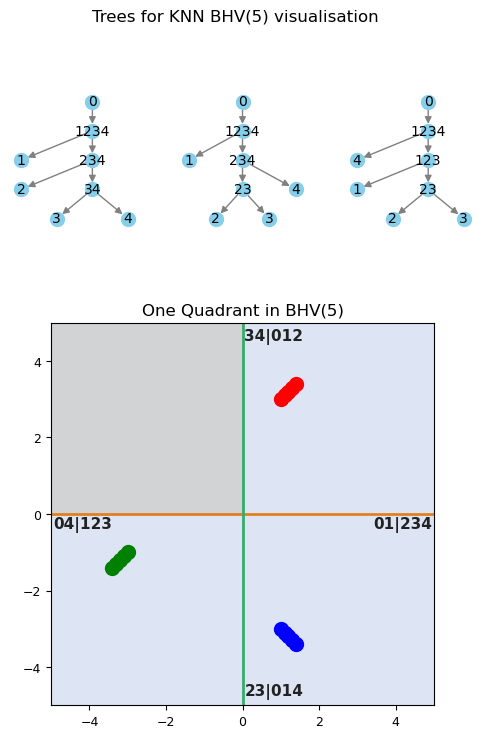

In [80]:
# Visualise
fig = plt.figure(figsize=(6, 8), facecolor="white")
grid = GridSpec(2, 3, figure=fig, height_ratios=[1, 2.7], hspace=0.35, wspace=0.3)

for i, tree in enumerate(X[::n_of_each]):
    ax = fig.add_subplot(grid[0, i])
    tree.plot(root_id=0, show_edge_weights=False, ax=ax)

ax_quad = fig.add_subplot(grid[1, :])
_draw_quadrant_plot(ax_quad, max_xy=5)
colors = ["red", "blue", "green"]
for i, (tree, pred_label) in enumerate(zip(X, knn.predict(X))):
    _draw_tree_on_quadrant(ax_quad, tree, c=colors[pred_label])

plt.suptitle("Trees for KNN BHV(5) visualisation")
plt.show()